# MNIST Classification

This notebook explores the MNIST dataset, a benchmark collection of handwritten digit images, and implements two models, KNN and Random Forest, to perform digit classification. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn import datasets
from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load MNIST dataset
X, y = datasets.fetch_openml('mnist_784', version=1, return_X_y=True)
X = np.asarray(X)
Y = np.asarray(y)

print('X shape', X.shape)
print('Y shape', Y.shape)

X shape (70000, 784)
Y shape (70000,)


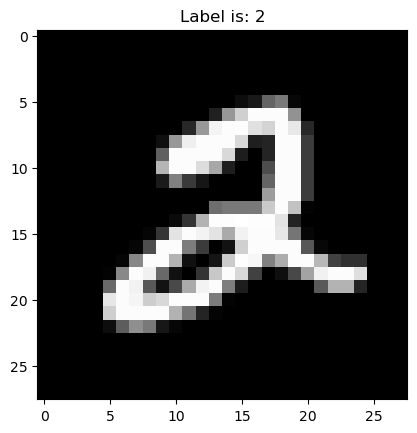

In [3]:
# Function to display a digit
def show_digit(x_, y_):
    X_reshape = x_.reshape(28, 28) # reshape it to have 28*28
    plt.imshow(X_reshape, 'gray')
    plt.title('Label is: ' + str(y_))
    plt.show()

show_digit(X[5],Y[5])

In [ ]:
test_percentage = 0.2   # split the data to have 20% test set and 80% training set

# Split the dataset into training set and test set
X_train, X_test, y_train, y_test = model_selection.train_test_split(X,Y, test_size= test_percentage, random_state=12)

In [5]:
# Normalize the data
max = np.max(X_train)

X_train = X_train / max # Normalize X_train based on the maximum value of X_train
X_test = X_test / max   # Normalize X_test  based on the maximum value of X_train

## KNN Classifier

In [6]:
R_train_KNN = []
R_test_KNN = []
Neighbours = np.arange(1,100,5)
for k in Neighbours:
    model = KNeighborsClassifier(n_neighbors=k)   # define KNN model
    model.fit(X_train, y_train)                   # fit the data
    y_res_train = model.predict(X_train)          # Output for training set
    y_res_test = model.predict(X_test)            # Output for test set
    R_train_KNN.append(sklearn.metrics.accuracy_score(y_train, y_res_train))
    R_test_KNN.append(sklearn.metrics.accuracy_score(y_test, y_res_test))

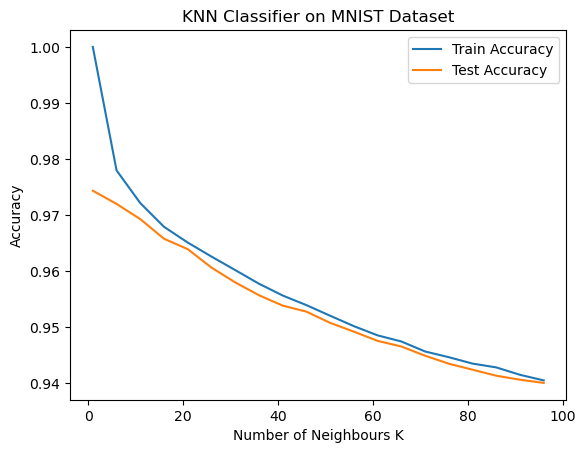

In [7]:
# Accuracy plot
plt.figure()
plt.plot(Neighbours, R_train_KNN, label='Train Accuracy')
plt.plot(Neighbours, R_test_KNN, label='Test Accuracy')
plt.xlabel('Number of Neighbours K')
plt.ylabel('Accuracy')
plt.title('KNN Classifier on MNIST Dataset')
plt.legend()
plt.show()

In [8]:
# Hyper-parameter search for KNN
best_k = Neighbours[np.argmax(R_test_KNN)]
print("Best K for KNN is:", best_k, "with test accuracy:", np.max(R_test_KNN))

Best K for KNN is: 1 with test accuracy: 0.9743571428571428


## Random Forest Classifier

In [ ]:
R_train_RF = []
R_test_RF = []
Min_sample = np.arange(5,51,5)
for s in Min_sample:
    model_RF = RandomForestClassifier(min_samples_leaf=s)  # define Random forest model
    model_RF.fit(X_train, y_train)                          # fit the data
    y_res_train = model_RF.predict(X_train)                 # Output for train set
    y_res_test = model_RF.predict(X_test)                   # Output for test set
    R_train_RF.append(sklearn.metrics.accuracy_score(y_train, y_res_train))
    R_test_RF.append(sklearn.metrics.accuracy_score(y_test, y_res_test))

In [ ]:
# Accuracy plot
plt.figure()
plt.plot(Min_sample, R_train_RF, label='Train Accuracy')
plt.plot(Min_sample, R_test_RF, label='Test Accuracy')
plt.xlabel('Min Samples per Leaf')
plt.ylabel('Accuracy')
plt.title('Random Forest Classifier on MNIST Dataset')
plt.legend()
plt.show()

In [ ]:
# Hyper-parameter search for Random Forest
best_s = Min_sample[np.argmax(R_test_RF)]
print("Best min_samples_leaf for Random Forest is:", best_s, "with test accuracy:", np.max(R_test_RF))